# 1. Loading

In [170]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from loguru import logger
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.model_selection import KFold, TimeSeriesSplit, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from pygam import LinearGAM, s, l, te
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted

random_seed = 42

In [171]:
TIME_SPLIT = False

In [172]:
WINDOW_LENGTH = "5min"

In [173]:
notebook_dir = os.getcwd()
notebook_parent_dir = os.path.dirname(notebook_dir)
notebook_parent_parent_dir = os.path.dirname(notebook_parent_dir)
engineered_data_path = os.path.join(notebook_parent_parent_dir, 'data', 'engineered', f'engineered_features_{WINDOW_LENGTH}.csv')

In [174]:
df = pd.read_csv(engineered_data_path)
df["window_start"] = pd.to_datetime(df["window_start"], format='ISO8601', utc=True)

In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47597 entries, 0 to 47596
Data columns (total 59 columns):
 #   Column                                                                 Non-Null Count  Dtype              
---  ------                                                                 --------------  -----              
 0   seg_id                                                                 47597 non-null  int64              
 1   window_start                                                           47597 non-null  datetime64[us, UTC]
 2   Vessel Hull Over Ground Speed (knots)                                  47597 non-null  float64            
 3   Vessel Hull Through Water Longitudinal Speed (knots)                   47597 non-null  float64            
 4   Vessel External Conditions Wind Relative Speed (knots)                 47597 non-null  float64            
 5   Vessel External Conditions Wind Relative Angle (degrees)               47597 non-null  float64            
 6   V

# 3. Predictive models

This section defines a predictor set and benchmarks multiple machine learning models to predict shaft power.

## 3.1. Ridge vs GAM vs Random Forest

### 3.1.1. Setup

#### 3.1.1.1. Defining variables

In [176]:
TARGET_COLUMN = "Vessel Propeller Shaft Mechanical Power (KW)"

predictive_sensor_variables = [
    "Avg Draft (Calculated)",
    "Draft Trim (Calculated)",
    "Days Since Last Cleaning",
    "Vessel Hull Through Water Longitudinal Speed (knots)",
#   "Speed x DSC (calculated)"
#   "Speed Through Water^3 (m/s)",
#   "Speed^3 x DSC (calculated)",
#   "Vessel Propeller Shaft Thrust Force (KN)",
]

predictive_weather_variables = [
    "Vessel External Conditions Wind Relative Angle (degrees)",
    "Vessel External Conditions Wind Relative Speed (knots)",
    "Vessel External Conditions Sea Water Temperature (Provider S)",
#    "Vessel External Conditions Northward Sea Water Velocity (Provider MB)", # Make a current variable instead
#    "Vessel External Conditions Eastward Sea Water Velocity (Provider MB)", # Make a current variable instead 
    "Vessel External Conditions Wave Significant Height (Provider MB)",
#    "Vessel External Conditions Swell Significant Height (Provider MB)", # choose either swell or wave due to collinearity
#    "Vessel External Conditions Eastward Wind Velocity (Provider S)",
#    "Vessel External Conditions Wind True Angle (Provider MB)",
#    "Vessel External Conditions Wind True Speed (Provider MB)",
]

all_predictive_variables = predictive_sensor_variables + predictive_weather_variables

print(f"Target variable: {TARGET_COLUMN}")
print(f"Number of predictive variables: {len(all_predictive_variables)}")
print("Predictive variables:")
for variable in all_predictive_variables:
    print(f"- {variable}")


# Conditionally select speed variable based on availability
if "Vessel Hull Through Water Longitudinal Speed (knots)" in all_predictive_variables:
    speed_variable = "Vessel Hull Through Water Longitudinal Speed (knots)"
elif "Speed Through Water^3 (m/s)" in all_predictive_variables:
    speed_variable = "Speed Through Water^3 (m/s)"
else:
    raise ValueError("Neither 'Vessel Hull Through Water Longitudinal Speed (knots)' nor 'Speed Through Water^3 (m/s)' found in predictive variables")

dsc_variable = "Days Since Last Cleaning"
draft_variables = [feature for feature in all_predictive_variables if "Draft" in feature]
non_draft_variables = [feature for feature in all_predictive_variables if "Draft" not in feature and feature != speed_variable and feature != dsc_variable]
draft_and_non_draft_variables = draft_variables + non_draft_variables

Target variable: Vessel Propeller Shaft Mechanical Power (KW)
Number of predictive variables: 8
Predictive variables:
- Avg Draft (Calculated)
- Draft Trim (Calculated)
- Days Since Last Cleaning
- Vessel Hull Through Water Longitudinal Speed (knots)
- Vessel External Conditions Wind Relative Angle (degrees)
- Vessel External Conditions Wind Relative Speed (knots)
- Vessel External Conditions Sea Water Temperature (Provider S)
- Vessel External Conditions Wave Significant Height (Provider MB)


#### 3.1.1.2. Loading data

In [177]:
model_df = (
    df[["window_start", TARGET_COLUMN] + all_predictive_variables]
    .sort_values("window_start")
    .dropna()
    .copy()
)

X = model_df[all_predictive_variables]
y = model_df[TARGET_COLUMN]

print(f"Rows available for modelling: {len(model_df):,}")
print(f"Feature matrix shape: {X.shape}")

Rows available for modelling: 47,597
Feature matrix shape: (47597, 8)


#### 3.1.1.3. specifying models and pipeline components

In [178]:
# --- GAM formula construction ---
gam_formula = None


# Track indices for the tensor product interaction
speed_idx = None
days_cleaning_idx = None


for i, var_name in enumerate(all_predictive_variables):
   
    if var_name == "Days Since Last Cleaning":
        days_cleaning_idx = i  # <-- capture index
        term = s(i, constraints='monotonic_inc', n_splines=15)
       
    elif var_name == "Vessel Hull Through Water Longitudinal Speed (knots)":
        speed_idx = i  # <-- capture index
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Speed Through Water^3 (m/s)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Speed^3 x DSC (calculated)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Speed x DSC (calculated)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    elif var_name == "Avg Draft (Calculated)":
        term = s(i, constraints='monotonic_inc', n_splines=10)
       
    elif var_name == "Vessel External Conditions Sea Water Temperature (Provider S)":
        term = s(i, constraints='monotonic_dec', n_splines=10)
   
    elif var_name == "Vessel External Conditions Wave Significant Height (Provider MB)":
        term = s(i, constraints='monotonic_inc', n_splines=10)
       
    elif var_name == "Vessel External Conditions Swell Significant Height (Provider MB)":
        term = s(i, constraints='monotonic_inc', n_splines=10)

    elif var_name == "Vessel External Conditions Wind Relative Angle (degrees)":
        term = s(i, basis='cp', n_splines=10, edge_knots=[0, 360])

    elif var_name == "Vessel External Conditions Wind Relative Speed (knots)":
        term = s(i, constraints='monotonic_inc', n_splines=15)

    else:
        term = s(i, n_splines=10)
       
    if gam_formula is None:
        gam_formula = term
    else:
        gam_formula += term

# --- Wrapper Class ---
class SklearnGAM(BaseEstimator, RegressorMixin):
    def __init__(self, formula, auto_tune=True):
        self.formula = formula
        self.auto_tune = auto_tune
       
    def fit(self, X, y):
        self.gam_model_ = LinearGAM(self.formula)
       
        if self.auto_tune:
            # Provide a wider grid for the smoothing penalty (up to 100,000). Lower bound was expanded from -3 to allow for a more "wiggly" curves
            lam_grid = np.logspace(-6, 3, 20)
            self.gam_model_.gridsearch(X, y, lam=lam_grid)
        else:
            self.gam_model_.fit(X, y)
           
        self.is_fitted_ = True
        return self


    def predict(self, X):
        check_is_fitted(self, 'is_fitted_')
        return self.gam_model_.predict(X)

In [179]:
if TIME_SPLIT:        
    split_index = int(len(model_df) * 0.8)

    X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)


numeric_preprocessor = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, all_predictive_variables),
    ]
)

models = {
    "GAM": SklearnGAM(formula=gam_formula),
#    "Ridge": Ridge(alpha=1.0),
#    "RandomForest": RandomForestRegressor(n_estimators=500, random_state=random_seed, n_jobs=-1, max_features='sqrt', min_samples_split=2)
}

print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")

Train rows: 38,077
Test rows:  9,520


### 3.1.2. Running pipeline

In [180]:
if TIME_SPLIT:
    logger.info("Using TimeSeriesSplit for cross-validation.")
    tscv = TimeSeriesSplit(n_splits=5)
if not TIME_SPLIT:
    logger.info("Using KFold for cross-validation.")
    tscv = KFold(n_splits=5, shuffle=True, random_state=random_seed)

scoring = {
    "mape": "neg_mean_absolute_percentage_error",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}

results = []
fitted_pipelines = {}

# Make sure you define your scoring metrics for the CV function
scoring = {
    "mape": "neg_mean_absolute_percentage_error",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}

for model_name, estimator in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator),
        ]
    )

    # 1. Run Cross-Validation and keep both train and test (validation) fold scores
    cv_scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=tscv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True, # Changed to True so you can see CV fold training scores
    )

    # 2. Fit the final model on the ENTIRE training set
    pipeline.fit(X_train, y_train)
    
    # 3. Predict on train and test sets
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)

    # 4. Save the results, incorporating the CV scores!
    results.append(
        {
            "model": model_name,
            
            # RMSE 
            "train_rmse": root_mean_squared_error(y_train, y_pred_train),
            "cv_rmse_mean": -cv_scores["test_rmse"].mean(),
            "cv_rmse_std": cv_scores["test_rmse"].std(),
            "test_rmse": root_mean_squared_error(y_test, y_pred_test),
            
            # MAPE
            "train_mape": mean_absolute_percentage_error(y_train, y_pred_train),
            "cv_mape_mean": -cv_scores["test_mape"].mean(),
            "cv_mape_std": cv_scores["test_mape"].std(),
            "test_mape": mean_absolute_percentage_error(y_test, y_pred_test),
            
            # MAE
            "train_mae": mean_absolute_error(y_train, y_pred_train),
            "cv_mae_mean": -cv_scores["test_mae"].mean(),
            "cv_mae_std": cv_scores["test_mae"].std(),
            "test_mae": mean_absolute_error(y_test, y_pred_test),
        }
    )

    fitted_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values("test_rmse", ascending=True)
results_df.reset_index(drop=True, inplace=True)
display(results_df)

2026-02-25 10:43:22.324 | INFO     | __main__:<module>:5 - Using KFold for cross-validation.
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (0 of 20) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 15% (3 of 20) |###                      | Elapsed Time: 0:00:00 ETA:   0:00:00
 30% (6 of 20) |#######                  | Elapsed Time: 0:00:00 ETA:   0:00:00
 30% (6 of 20) |#######    

,model,train_rmse,cv_rmse_mean,cv_rmse_std,test_rmse,train_mape,cv_mape_mean,cv_mape_std,test_mape,train_mae,cv_mae_mean,cv_mae_std,test_mae
0,GAM,493.764519,1492.95389,4.502476,496.362624,0.090454,0.386908,0.003249,0.089908,366.181299,1378.779414,5.006339,365.394506


In [181]:
# Add speed column calculated from speed cubed, if only speed cubed is available
if "Vessel Hull Through Water Longitudinal Speed (knots)" not in df.columns and "Speed Through Water^3 (m/s)" in df.columns:
    df["Vessel Hull Through Water Longitudinal Speed (knots)"] = np.cbrt(df["Speed Through Water^3 (m/s)"])
    all_predictive_variables.append("Vessel Hull Through Water Longitudinal Speed (knots)")

### 3.1.3. Quick residual diagnostics

Text(0, 0.5, 'Frequency')

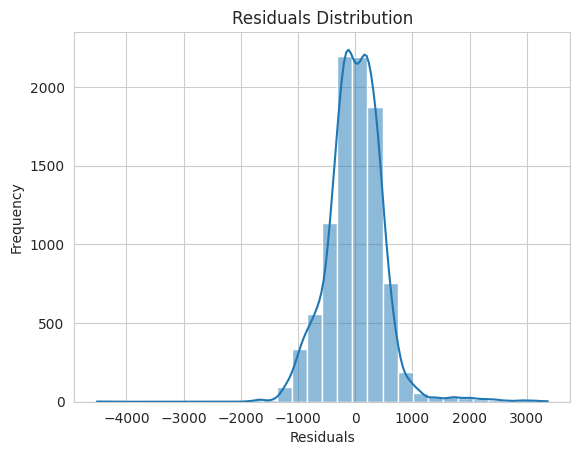

In [182]:
rmse = root_mean_squared_error(y_test, y_pred_test)  # true RMSE [web:156]

histogram = sns.histplot(y_test - y_pred_test, bins=30, kde=True)
histogram.set_title("Residuals Distribution")
histogram.set_xlabel("Residuals")
histogram.set_ylabel("Frequency")

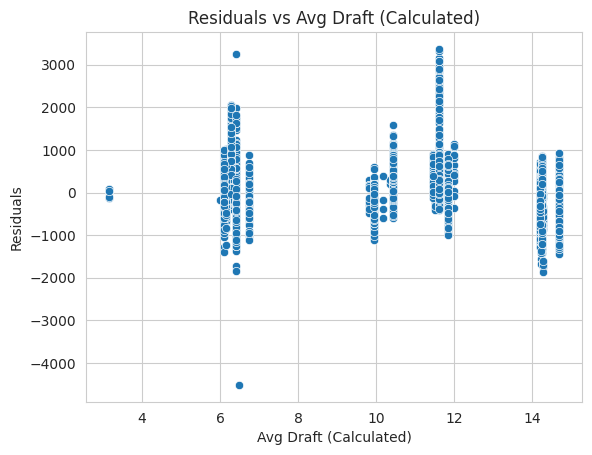

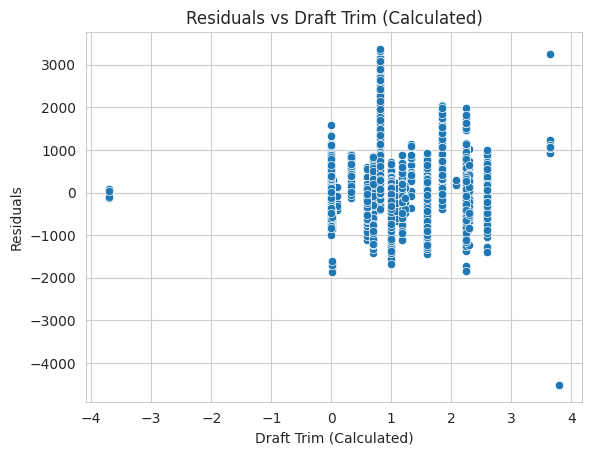

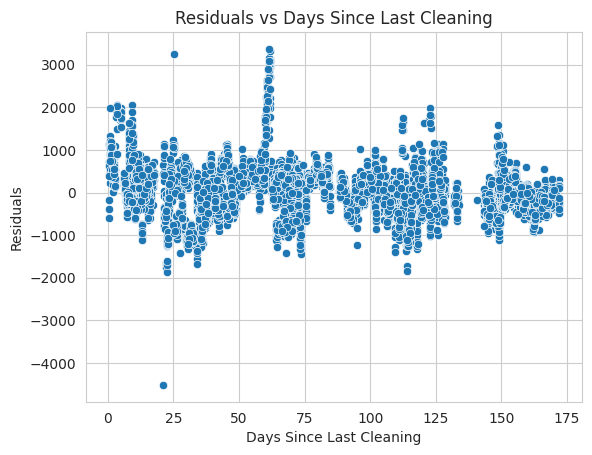

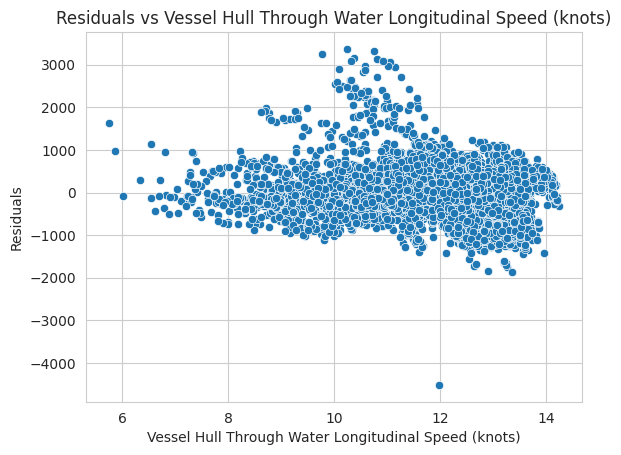

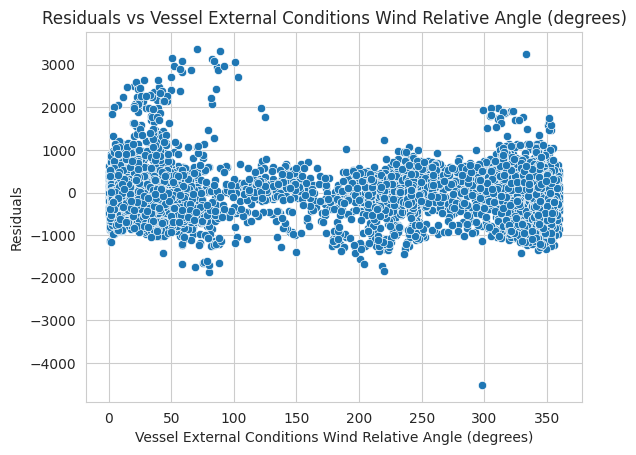

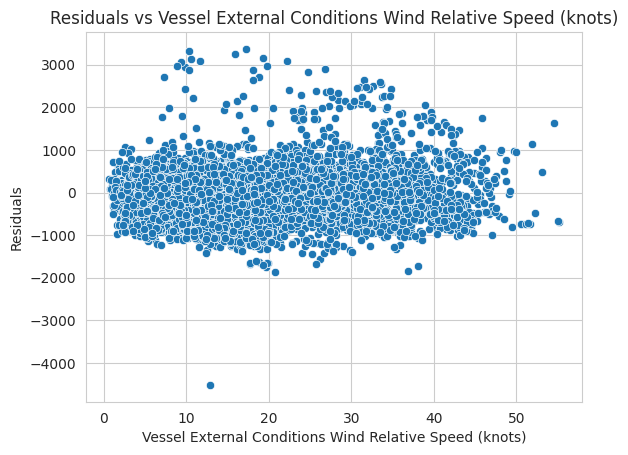

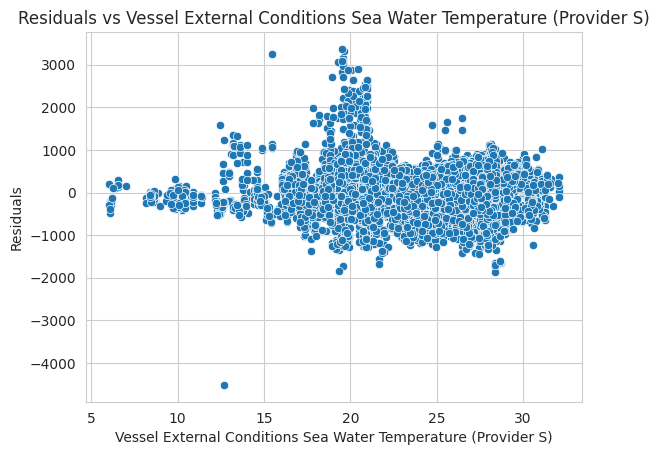

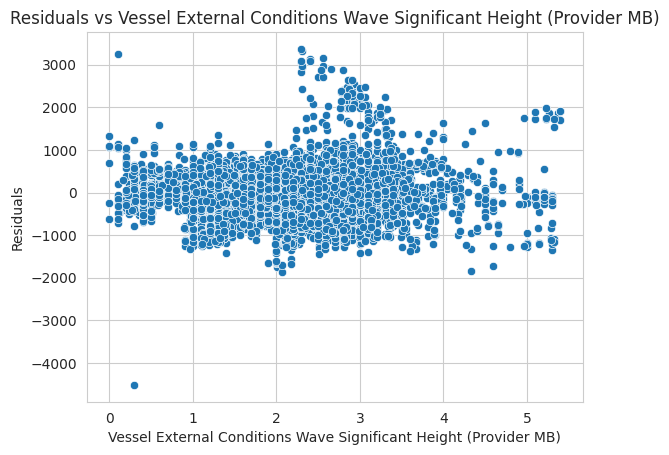

In [183]:
# make scatterplot of the residuals vs the actual values, as well as each of the features (to see what what kind of values it is struggling to predict)
for feature in all_predictive_variables:
    scatter = sns.scatterplot(x=X_test[feature], y=y_test - y_pred_test)
    scatter.set_title(f"Residuals vs {feature}")
    scatter.set_xlabel(feature)
    scatter.set_ylabel("Residuals")
    plt.show()


## 3.2. Synthetic test scenario

### 3.2.1. Setting values

In [184]:
speed_values = [8, 8.5, 9, 9.5,10, 10.5, 11, 11.5, 12, 12.5, 13, 13.5, 14] # for varying speed
dsc_range = range(0, 151, 1) # for varying fouling from 0 to 150 days since cleaning

# split the list of predictive variables into draft and non draft by looking for the word "draft" in the variable name

logger.info(f'speed variable: {speed_variable}')
logger.info(f'dsc variable: {dsc_variable}')
logger.info(f"Draft variables: {draft_variables}")
logger.info(f"Non-draft variables: {non_draft_variables}")

# intialize a dictionary and set the keys to be the selected predictive variable names execpt for dsc
typical_values = {feature: [] for feature in all_predictive_variables}

# drop the speed and cleaning date variables from the typical values dict
typical_values.pop(dsc_variable, None)
typical_values.pop(speed_variable, None)

# for the values in the dictionary, take the mean value of each feature in the training set ofr the non-draft variables, and for the draft variables, set them to be the median
for feature in all_predictive_variables:
    if feature in non_draft_variables:
        typical_values[feature] = X_train[feature].mean()
    elif feature in draft_variables:
        # set draft variables to be the median instead
        typical_values[feature] = X_train[feature].median()

typical_values

2026-02-25 10:46:42.660 | INFO     | __main__:<module>:6 - speed variable: Vessel Hull Through Water Longitudinal Speed (knots)
2026-02-25 10:46:42.662 | INFO     | __main__:<module>:7 - dsc variable: Days Since Last Cleaning
2026-02-25 10:46:42.663 | INFO     | __main__:<module>:8 - Draft variables: ['Avg Draft (Calculated)', 'Draft Trim (Calculated)']
2026-02-25 10:46:42.664 | INFO     | __main__:<module>:9 - Non-draft variables: ['Vessel External Conditions Wind Relative Angle (degrees)', 'Vessel External Conditions Wind Relative Speed (knots)', 'Vessel External Conditions Sea Water Temperature (Provider S)', 'Vessel External Conditions Wave Significant Height (Provider MB)']


{'Avg Draft (Calculated)': np.float64(9.945),
 'Draft Trim (Calculated)': np.float64(1.0),
 'Vessel External Conditions Wind Relative Angle (degrees)': np.float64(205.2431728161802),
 'Vessel External Conditions Wind Relative Speed (knots)': np.float64(21.467125335156222),
 'Vessel External Conditions Sea Water Temperature (Provider S)': np.float64(24.299006186380847),
 'Vessel External Conditions Wave Significant Height (Provider MB)': np.float64(2.0123813819983964)}

### 3.2.2. Build synhtetic test set

In [185]:
# build a dataframe with a column for each of the "all predictive variables", and a row for each combination of speed and days since cleaning, where the values in the dataframe are the typical values for each variable, except for speed and days since cleaning which take the values from the lists defined above
simulation_df = pd.DataFrame(columns=all_predictive_variables)
for speed in speed_values:
    for dsc in dsc_range:
        row = {feature: typical_values[feature] for feature in draft_and_non_draft_variables}
        row[speed_variable] = speed
        row[dsc_variable] = dsc
        simulation_df = pd.concat([simulation_df, pd.DataFrame([row])], ignore_index=True)


logger.info(f"Simulation dataframe shape: {simulation_df.shape}")

2026-02-25 10:46:45.409 | INFO     | __main__:<module>:11 - Simulation dataframe shape: (1963, 8)


#### 3.2.2.1 add predictions

In [186]:
# get a pipeline for the n'th model in the "models" object
n = 0
model_name = list(models.keys())[n]
chosen_pipeline = fitted_pipelines[model_name]
model_name

'GAM'

In [187]:
# Scale the simulation features based on the scaler from the best pipeline
simulation_df["Predicted Shaft Power"] = chosen_pipeline.predict(simulation_df)

# Display as a scrollable table
display(simulation_df.style.set_table_attributes("style='display:block; max-height:500px; overflow:auto;'"))



,Avg Draft (Calculated),Draft Trim (Calculated),Days Since Last Cleaning,Vessel Hull Through Water Longitudinal Speed (knots),Vessel External Conditions Wind Relative Angle (degrees),Vessel External Conditions Wind Relative Speed (knots),Vessel External Conditions Sea Water Temperature (Provider S),Vessel External Conditions Wave Significant Height (Provider MB),Predicted Shaft Power
0,9.945000,1.000000,0,8,205.243173,21.467125,24.299006,2.012381,1269.569521
1,9.945000,1.000000,1,8,205.243173,21.467125,24.299006,2.012381,1269.569504
2,9.945000,1.000000,2,8,205.243173,21.467125,24.299006,2.012381,1269.569485
3,9.945000,1.000000,3,8,205.243173,21.467125,24.299006,2.012381,1269.569465
4,9.945000,1.000000,4,8,205.243173,21.467125,24.299006,2.012381,1269.569443
5,9.945000,1.000000,5,8,205.243173,21.467125,24.299006,2.012381,1269.569419
6,9.945000,1.000000,6,8,205.243173,21.467125,24.299006,2.012381,1269.569393
7,9.945000,1.000000,7,8,205.243173,21.467125,24.299006,2.012381,1269.569367
8,9.945000,1.000000,8,8,205.243173,21.467125,24.299006,2.012381,1269.569338
9,9.945000,1.000000,9,8,205.243173,21.467125,24.299006,2.012381,1269.569309


In [188]:
# for each value of speed in the synthetic dataframe, print the number of unique values and descriptive statistics for the predicted shaft power
for speed in speed_values:
    speed_df = simulation_df[simulation_df[speed_variable] == speed]
    logger.info(f"Speed: {speed} knots")
    logger.info(f"Number of unique predicted shaft power values: {speed_df['Predicted Shaft Power'].nunique()}")
    logger.info(f"Descriptive statistics for predicted shaft power:\n{speed_df['Predicted Shaft Power'].describe()}")

2026-02-25 10:46:46.174 | INFO     | __main__:<module>:4 - Speed: 8 knots
2026-02-25 10:46:46.177 | INFO     | __main__:<module>:5 - Number of unique predicted shaft power values: 151
2026-02-25 10:46:46.182 | INFO     | __main__:<module>:6 - Descriptive statistics for predicted shaft power:
count     151.000000
mean     1437.614622
std       105.535742
min      1269.569142
25%      1305.685107
50%      1515.893150
75%      1515.895878
max      1515.899208
Name: Predicted Shaft Power, dtype: float64
2026-02-25 10:46:46.185 | INFO     | __main__:<module>:4 - Speed: 8.5 knots
2026-02-25 10:46:46.187 | INFO     | __main__:<module>:5 - Number of unique predicted shaft power values: 151
2026-02-25 10:46:46.190 | INFO     | __main__:<module>:6 - Descriptive statistics for predicted shaft power:
count     151.000000
mean     1443.071023
std       105.535742
min      1275.025544
25%      1311.141509
50%      1521.349552
75%      1521.352280
max      1521.355610
Name: Predicted Shaft Power, dty

### 3.2.3. Analyse

In [189]:
def plot_speed_power_by_dsc(df, dsc_values):
    """
    Plots Speed vs Predicted Power for specific Days Since Last Cleaning (DSC) values.

    Parameters:
    - df: pandas DataFrame containing the synthetic test set.
    - dsc_values: list of integers representing the specific DSC days to plot (e.g., [0, 50, 100]).
    """
    
    # Define column names based on your dataframe
    col_speed = 'Vessel Hull Through Water Longitudinal Speed (knots)'
    col_power = 'Predicted Shaft Power'
    col_dsc = 'Days Since Last Cleaning'
    
    # 1. Filter the dataframe to only include the requested DSC values
    plot_data = df[df[col_dsc].isin(dsc_values)].copy()
    
    # Check if data exists after filtering
    if plot_data.empty:
        print("Warning: No data found for the provided DSC values.")
        return

    # 2. Setup the plot
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # 3. Create the scatterplot
    # We convert 'col_dsc' to categorical types/strings temporarily for the hue 
    # to ensure distinct colors (discrete palette) instead of a gradient.
    sns.scatterplot(
        data=plot_data,
        x=col_speed, 
        y=col_power, 
        hue=col_dsc,
        palette="viridis",  # Color map
        s=75,              # Dot size
        edgecolor='none',  # Add border to dots for clarity
        alpha=1           # Slight transparency
    )
    
    # 4. Formatting
    plt.title('Speed vs Predicted Power at Different Fouling Levels', fontsize=14)
    plt.xlabel('Speed (knots)', fontsize=12)
    plt.ylabel('Predicted Shaft Power', fontsize=12)
    plt.legend(title='Days Since Last Cleaning', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

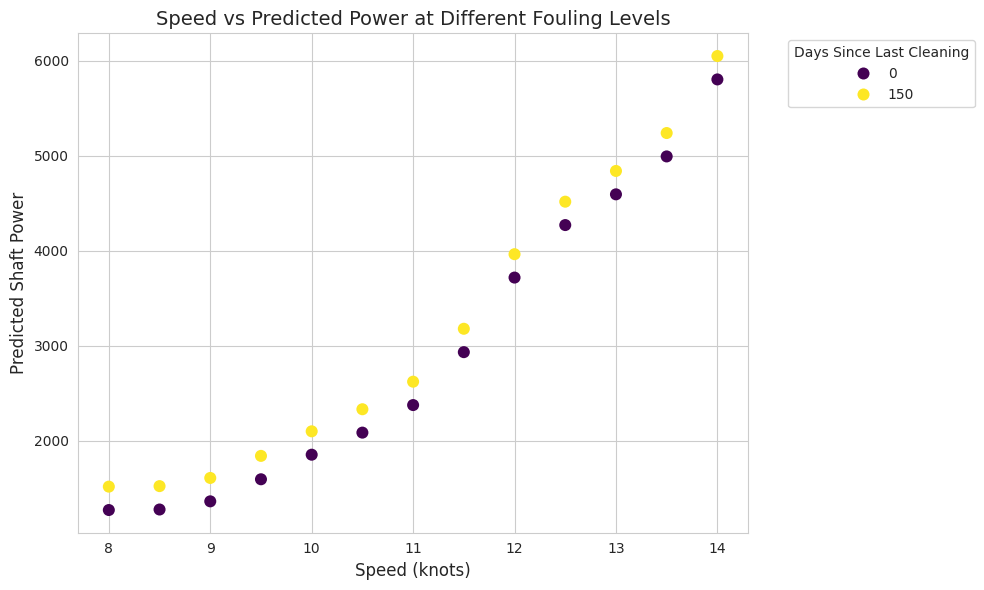

In [190]:
plot_speed_power_by_dsc(simulation_df, dsc_values=[0,150])

In [191]:
fouling_idx = all_predictive_variables.index("Days Since Last Cleaning")
print(f"Fouling is at index: {fouling_idx}")

Fouling is at index: 2


## 3.3. GAM model

### 3.3.1. Model summary & diagnostics

Checks already confirmed:

Concurvity: Neutralized by monotonic constraints

Speed-Power Curve: Visually confirmed to follow a $V^3$ curve

Fouling Curve: Confirmed to follow a biological S-curve shape

Overfitting: Confirmed resolved (Train RMSE ≈ Test RMSE)

EDoF vs. Lambda: Confirmed model is using appropriate flexibility

Physical constraints: Confirmed monotonic on Speed, DSC, Draft, Wave Height

#### 3.3.1.1. Summary

The EDoF should not be too close to n_splines (then n_splines should be increased)

In [192]:
# 1. Extract the raw pyGAM model from our fitted pipeline
gam_pipeline = fitted_pipelines["GAM"]
actual_pygam_model = gam_pipeline.named_steps["model"].gam_model_
# 2. Generate a perfectly spaced grid of 100 points for the fouling feature
# This creates a synthetic array where ONLY the fouling feature changes.
XX = actual_pygam_model.generate_X_grid(term=fouling_idx)

# 3. Extract the partial dependence (the isolated kW penalty) and the 95% confidence intervals
pdep, confi = actual_pygam_model.partial_dependence(term=fouling_idx, X=XX, width=0.95)

# 4. We only want to plot the X-axis for the fouling variable itself
x_axis_values = XX[:, fouling_idx]

In [193]:
all_predictive_variables

['Avg Draft (Calculated)',
 'Draft Trim (Calculated)',
 'Days Since Last Cleaning',
 'Vessel Hull Through Water Longitudinal Speed (knots)',
 'Vessel External Conditions Wind Relative Angle (degrees)',
 'Vessel External Conditions Wind Relative Speed (knots)',
 'Vessel External Conditions Sea Water Temperature (Provider S)',
 'Vessel External Conditions Wave Significant Height (Provider MB)']

In [194]:
actual_pygam_model.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     32.1004
Link Function:                     IdentityLink Log Likelihood:                               -290184.7192
Number of Samples:                        38077 AIC:                                           580435.6393
                                                AICc:                                          580435.6986
                                                GCV:                                           244379.9211
                                                Scale:                                            493.9728
                                                Pseudo R-Squared:                                   0.8906
Feature Function                  Lam

/tmp/ipykernel_27250/4038382217.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  actual_pygam_model.summary()


#### 3.3.1.2. Concurvity check

In [195]:
# Assuming your dataframe is 'df' and these are your features
target_feature = 'Days Since Last Cleaning'
other_features = all_predictive_variables.copy() # Add your other continuous variables here
other_features.remove(target_feature)  # Remove the target feature from the list of other features

# 1. Isolate the target feature (y) and the others (X)
y_concurvity = X_train[target_feature]
X_concurvity = X_train[other_features]

# 2. Fit a GAM predicting Days Since Cleaning based on the other features
# We use s(0) + s(1) to apply splines to both Speed and Draft
concurvity_model = LinearGAM(s(0) + s(1)).fit(X_concurvity, y_concurvity)

# 3. Extract the R-squared (Explained Deviance)
# 0.0 means no concurvity. 1.0 means complete overlap (bad).
concurvity_index = concurvity_model.statistics_['pseudo_r2']['explained_deviance']

print(f"Concurvity Index for {target_feature}: {concurvity_index:.4f}")
if concurvity_index > 0.7:
    print("WARNING: Severe concurvity detected. The model cannot separate the effect of fouling from the other variables.")


Concurvity Index for Days Since Last Cleaning: 0.9725


#### 3.3.1.3. residuals v predicted values

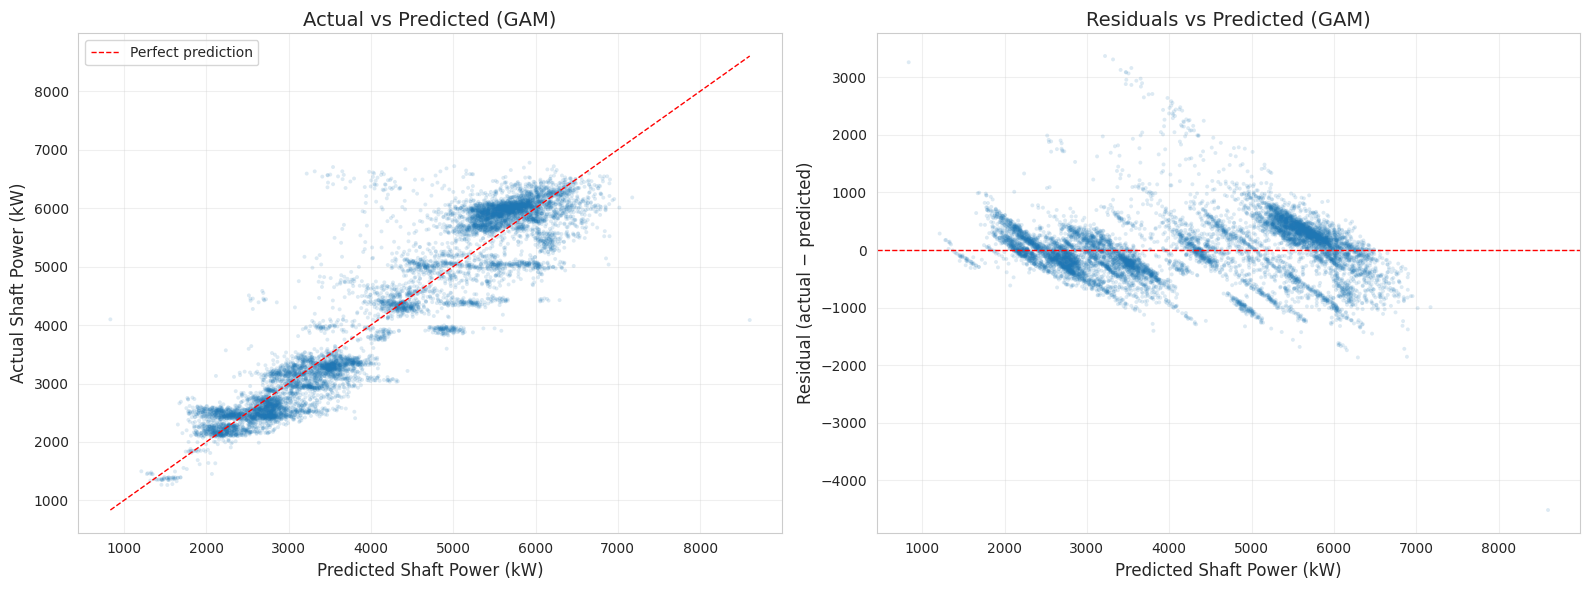

In [196]:
# Compute GAM-specific predictions on train and test sets
gam_pred_test = gam_pipeline.predict(X_test)
gam_pred_train = gam_pipeline.predict(X_train)
gam_residuals_test = np.asarray(y_test) - np.asarray(gam_pred_test)

# --- Residuals vs Predicted Values ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
axes[0].scatter(gam_pred_test, y_test, alpha=0.15, s=8, edgecolors='none')
lims = [
    min(gam_pred_test.min(), y_test.min()),
    max(gam_pred_test.max(), y_test.max()),
]
axes[0].plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel("Predicted Shaft Power (kW)", fontsize=12)
axes[0].set_ylabel("Actual Shaft Power (kW)", fontsize=12)
axes[0].set_title("Actual vs Predicted (GAM)", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals vs Predicted
axes[1].scatter(gam_pred_test, gam_residuals_test, alpha=0.15, s=8, edgecolors='none')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel("Predicted Shaft Power (kW)", fontsize=12)
axes[1].set_ylabel("Residual (actual − predicted)", fontsize=12)
axes[1].set_title("Residuals vs Predicted (GAM)", fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### 3.3.1.4. QQ plot / normality of residuals

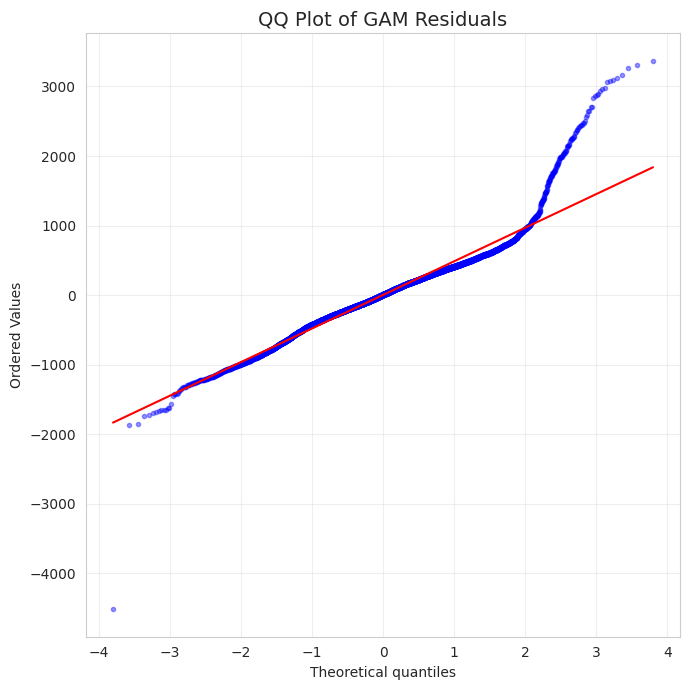

Shapiro-Wilk test  →  statistic = 0.948466,  p-value = 1.0403e-38
Residuals are NOT normally distributed (reject H₀ at α = 0.05).


In [197]:
from scipy import stats

# --- QQ Plot of GAM residuals ---
fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(gam_residuals_test, dist="norm", plot=ax)
ax.set_title("QQ Plot of GAM Residuals", fontsize=14)
ax.get_lines()[0].set(markersize=3, alpha=0.4)  # data points
ax.get_lines()[1].set(color='red', linewidth=1.5)  # reference line
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Shapiro-Wilk test on a subsample (max 5000 for performance)
sample = gam_residuals_test if len(gam_residuals_test) <= 5000 else np.random.default_rng(random_seed).choice(gam_residuals_test, 5000, replace=False)
stat, p_value = stats.shapiro(sample)
print(f"Shapiro-Wilk test  →  statistic = {stat:.6f},  p-value = {p_value:.4e}")
if p_value < 0.05:
    print("Residuals are NOT normally distributed (reject H₀ at α = 0.05).")
else:
    print("Residuals appear normally distributed (fail to reject H₀ at α = 0.05).")

#### 3.3.1.5. residuals over time

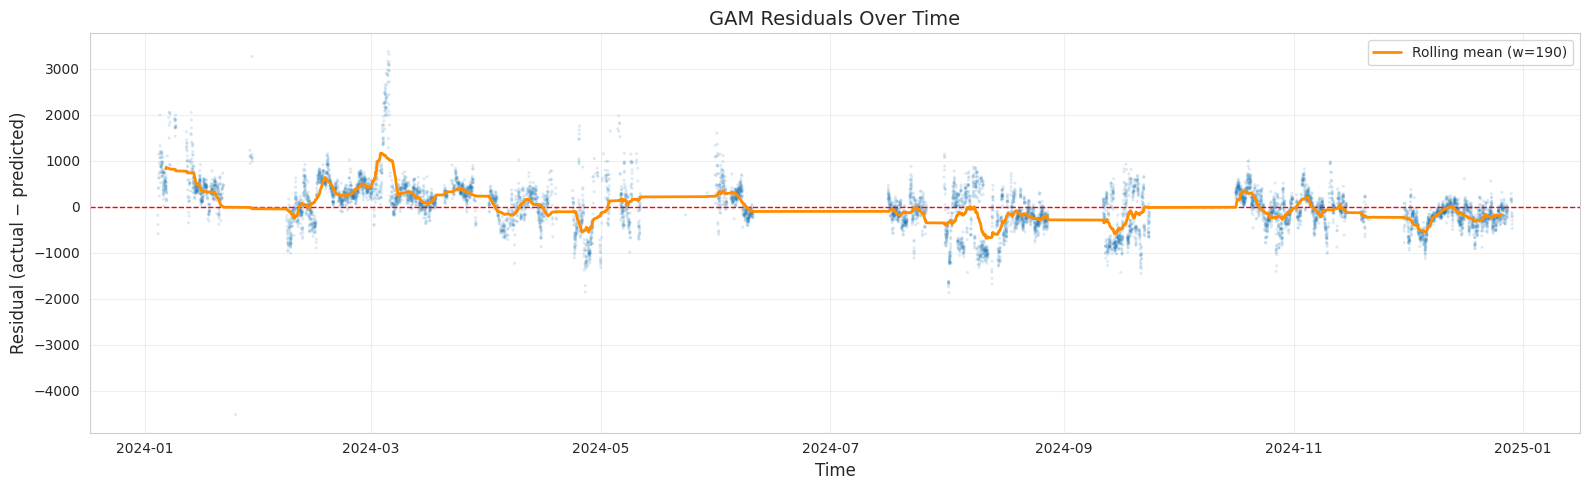

In [198]:
# --- Residuals over time ---
test_times = model_df.loc[X_test.index, "window_start"]

fig, ax = plt.subplots(figsize=(16, 5))
ax.scatter(test_times, gam_residuals_test, alpha=0.15, s=5, edgecolors='none')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)

# Rolling mean of residuals to highlight drift
rolling_df = pd.DataFrame({"time": test_times.values, "residual": gam_residuals_test}).sort_values("time")
window = max(len(rolling_df) // 50, 10)
rolling_mean = rolling_df["residual"].rolling(window=window, center=True).mean()
ax.plot(rolling_df["time"], rolling_mean, color='darkorange', linewidth=2, label=f'Rolling mean (w={window})')

ax.set_title("GAM Residuals Over Time", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Residual (actual − predicted)", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 3.3.1.6. Residuals vs days since cleaning

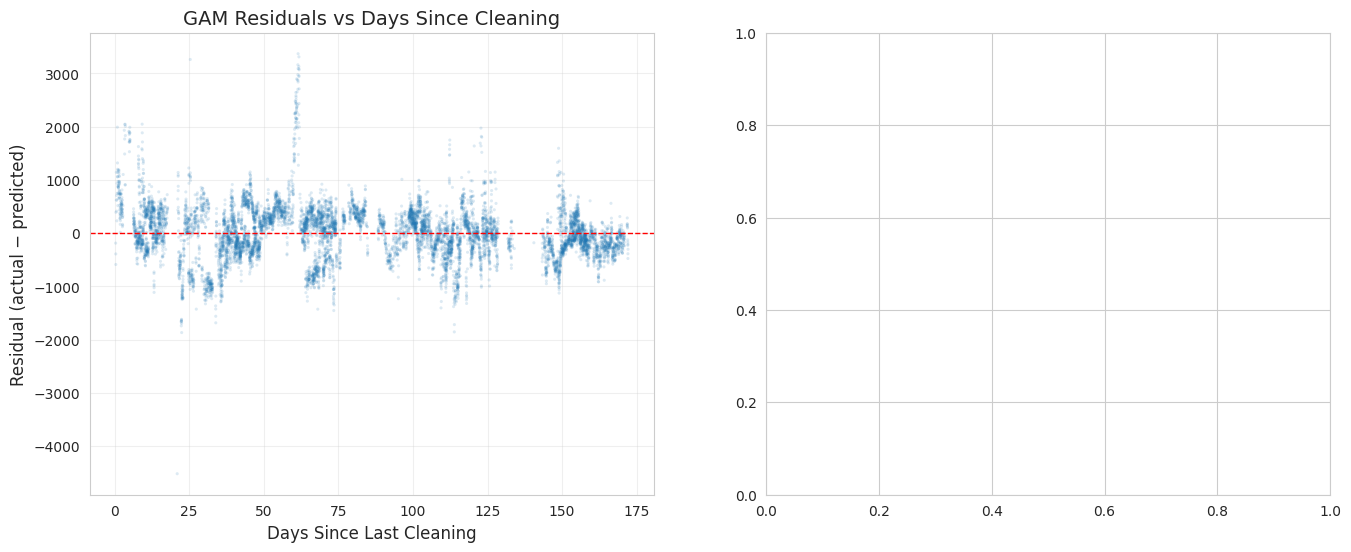

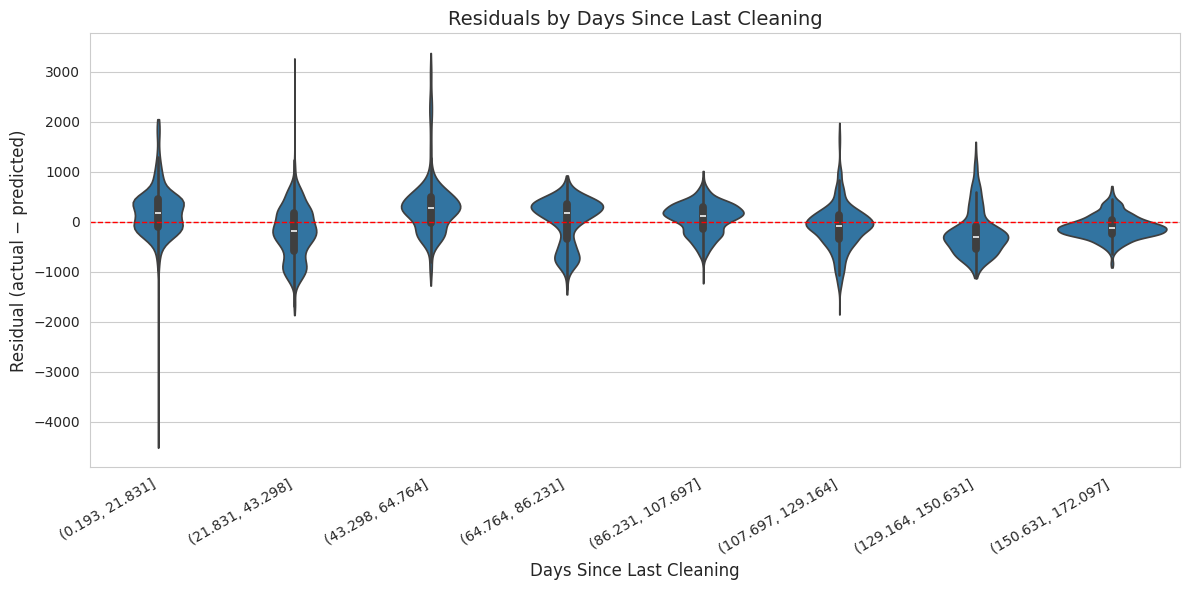

In [199]:
def plot_residual_boxplots(
    X_test,
    y_test,
    y_pred,
    variable_name,
    n_buckets=5,
    value_limits=None,
):
    """
    Creates a violin plot of residuals bucketed by a comparison variable.

    Parameters
    ----------
    X_test : pd.DataFrame
        Test feature matrix.
    y_test : pd.Series or np.ndarray
        True target values.
    y_pred : np.ndarray
        Predicted target values.
    variable_name : str
        Column name in X_test to bucket by.
    n_buckets : int, optional
        Number of equal-frequency (quantile) buckets (default 5).
    value_limits : tuple of (min, max), optional
        If provided, clips the comparison variable to [min, max] before
        bucketing, and drops rows outside this range.
    """
    residuals = np.asarray(y_test) - np.asarray(y_pred)
    plot_df = pd.DataFrame({
        "variable": X_test[variable_name].values,
        "residual": residuals,
    })

    # optional filtering by value limits
    if value_limits is not None:
        lo, hi = value_limits
        plot_df = plot_df[(plot_df["variable"] >= lo) & (plot_df["variable"] <= hi)]

    # create buckets using quantile-based binning
    plot_df["bucket"] = pd.cut(
        plot_df["variable"],
        bins=n_buckets,
        duplicates="drop",
    )

    # sort by bucket for a clean axis order
    plot_df = plot_df.sort_values("bucket")

    # plot
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.violinplot(
        data=plot_df,
        x="bucket",
        y="residual",
        ax=ax,
        inner="box",
        cut=0,
    )
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"Residuals by {variable_name}", fontsize=14)
    ax.set_xlabel(variable_name, fontsize=12)
    ax.set_ylabel("Residual (actual − predicted)", fontsize=12)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# --- Residuals vs Days Since Last Cleaning ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: scatter
axes[0].scatter(X_test["Days Since Last Cleaning"], gam_residuals_test, alpha=0.15, s=5, edgecolors='none')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel("Days Since Last Cleaning", fontsize=12)
axes[0].set_ylabel("Residual (actual − predicted)", fontsize=12)
axes[0].set_title("GAM Residuals vs Days Since Cleaning", fontsize=14)
axes[0].grid(True, alpha=0.3)

# Right: violin plot bucketed by DSC
plot_residual_boxplots(
    X_test=X_test,
    y_test=y_test,
    y_pred=gam_pred_test,
    variable_name="Days Since Last Cleaning",
    n_buckets=8,
)

#### 3.3.1.7. Sea trial curves validation


2026-02-25 10:46:52.274 | INFO     | __main__:<module>:14 - Rows within 7 days of a cleaning event: 856


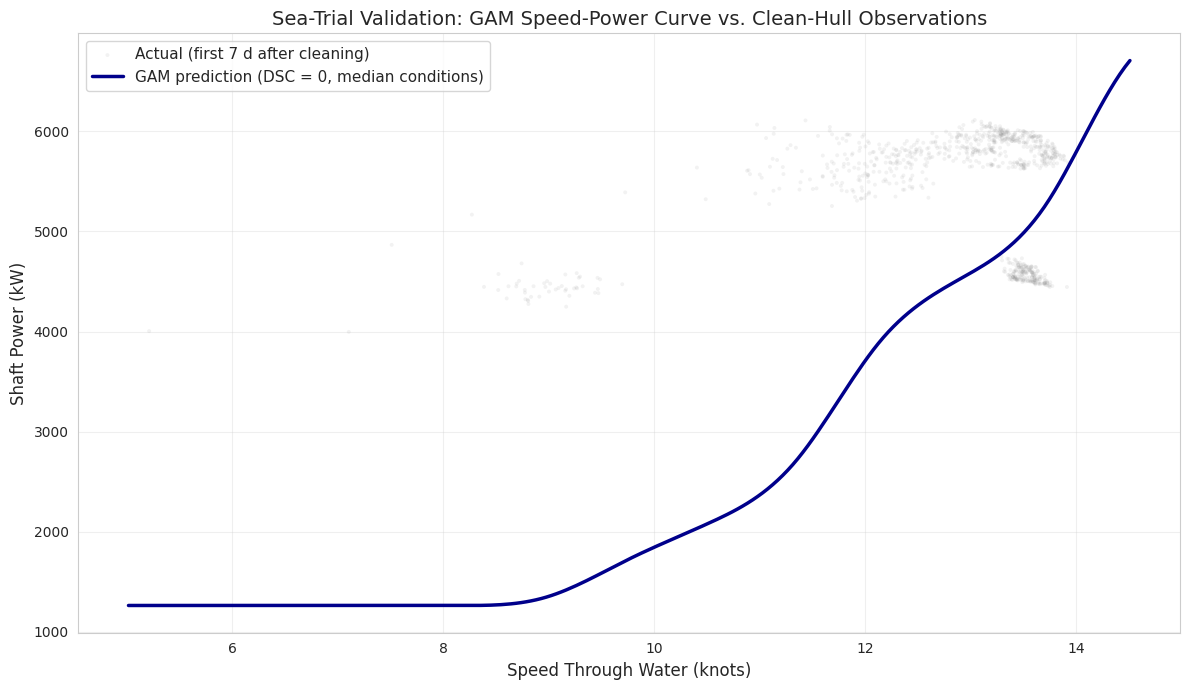

In [200]:
# --- 3.3.1.7  Sea Trial Curves Validation ---
# Compare the GAM's speed-power curve (at a clean-hull baseline) against
# actual observations from the first 7 days after each cleaning event.

CLEANING_DATES = [
    pd.Timestamp("2024-01-04", tz="UTC"),
    pd.Timestamp("2024-07-10", tz="UTC"),
]
CLEAN_HULL_DAYS = 7  # only keep the first N days after each cleaning

# 1. Identify rows within `CLEAN_HULL_DAYS` of any cleaning event
clean_hull_mask = model_df["Days Since Last Cleaning"] <= CLEAN_HULL_DAYS
clean_df = model_df[clean_hull_mask].copy()
logger.info(f"Rows within {CLEAN_HULL_DAYS} days of a cleaning event: {len(clean_df):,}")

# 2. Build a synthetic "sea trial" prediction from the GAM
#    Hold every variable at its typical (median) value except speed, and set DSC = 0.
speed_range = np.linspace(
    X_train[speed_variable].min(),
    X_train[speed_variable].max(),
    200,
)

sea_trial_rows = []
for spd in speed_range:
    row = {feat: X_train[feat].median() for feat in all_predictive_variables}
    row[speed_variable] = spd
    row[dsc_variable] = 0  # perfectly clean hull
    sea_trial_rows.append(row)

sea_trial_df = pd.DataFrame(sea_trial_rows)
sea_trial_df["Predicted Shaft Power"] = gam_pipeline.predict(sea_trial_df[all_predictive_variables])

# 3. Also predict on the real clean-hull observations for comparison
clean_pred = gam_pipeline.predict(clean_df[all_predictive_variables])

# 4. Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter: actual observations from the clean-hull period
ax.scatter(
    clean_df[speed_variable],
    clean_df[TARGET_COLUMN],
    alpha=0.10, s=8, edgecolors="none", color="grey",
    label=f"Actual (first {CLEAN_HULL_DAYS} d after cleaning)",
)

# Line: GAM prediction at DSC = 0 (synthetic sea-trial curve)
ax.plot(
    sea_trial_df[speed_variable],
    sea_trial_df["Predicted Shaft Power"],
    color="darkblue", linewidth=2.5,
    label="GAM prediction (DSC = 0, median conditions)",
)

ax.set_title("Sea-Trial Validation: GAM Speed-Power Curve vs. Clean-Hull Observations", fontsize=14)
ax.set_xlabel("Speed Through Water (knots)", fontsize=12)
ax.set_ylabel("Shaft Power (kW)", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### 3.3.1.8. Cleaning event reset check


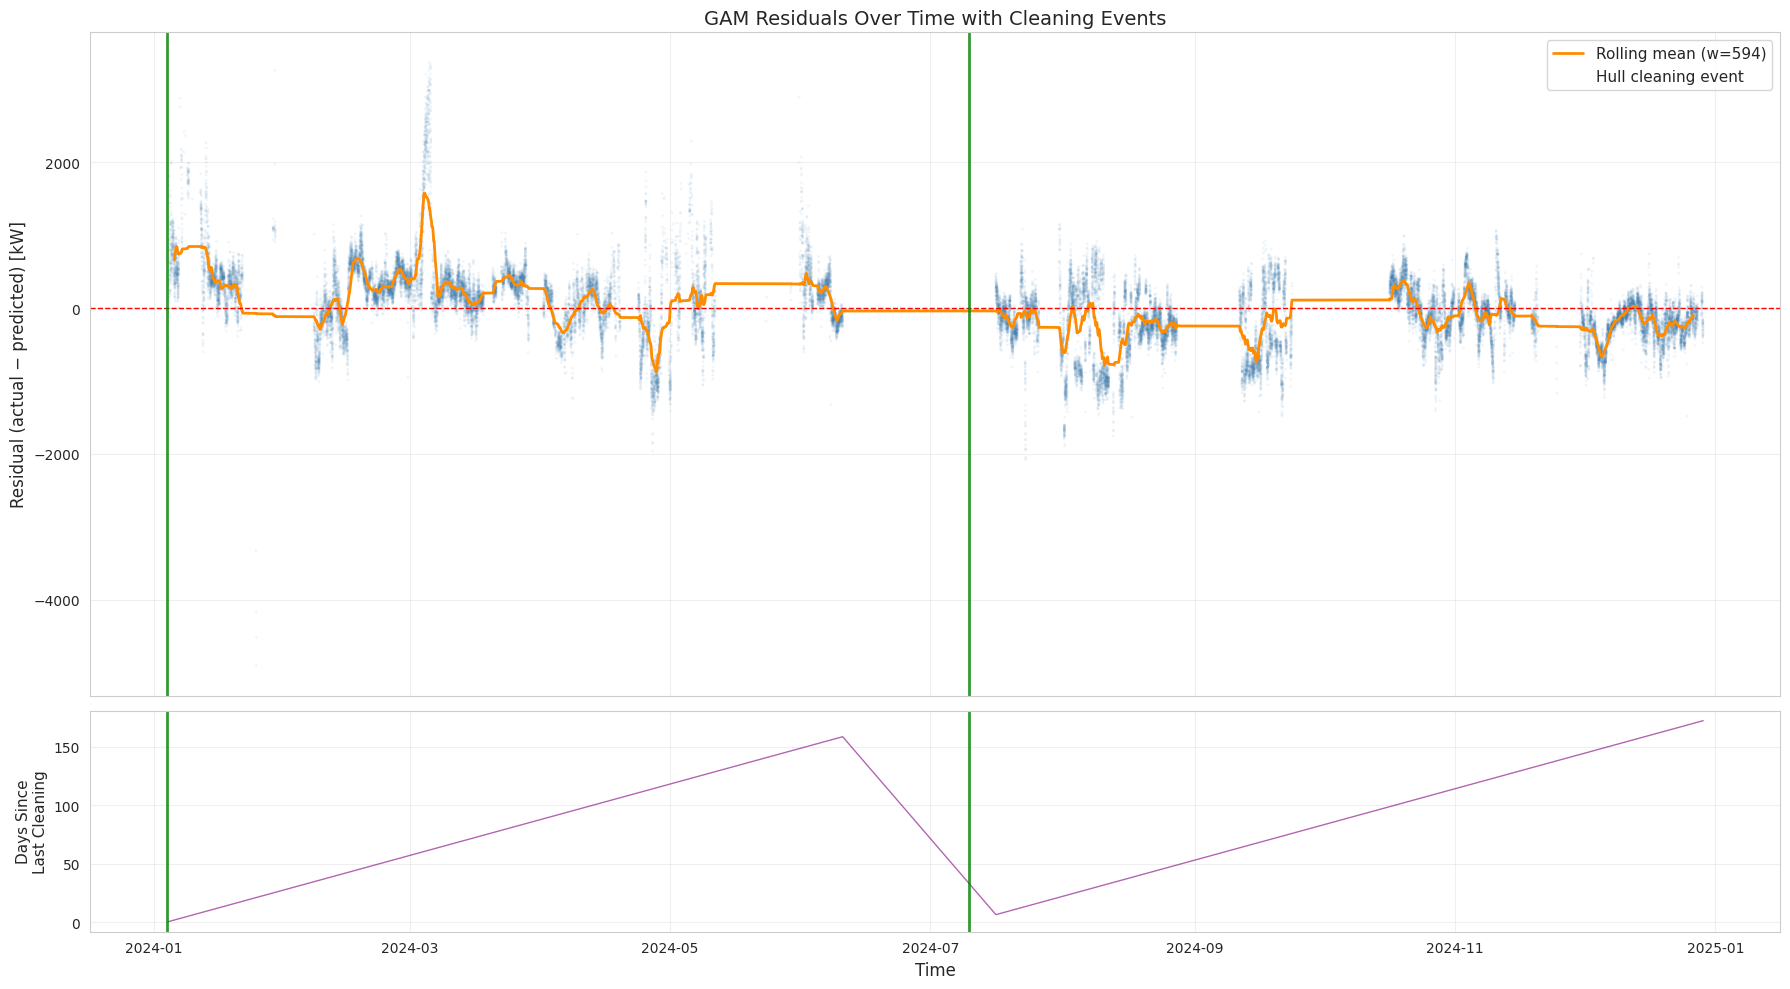

2026-02-25 10:46:55.443 | INFO     | __main__:<module>:69 - Mean residual  0-7 days after cleaning : +621.2 kW  (n=856)
2026-02-25 10:46:55.445 | INFO     | __main__:<module>:70 - Mean residual 90+ days after cleaning  : -82.1 kW  (n=21,574)
2026-02-25 10:46:55.447 | INFO     | __main__:<module>:71 - Difference (late − early)              : -703.2 kW


In [201]:
# --- 3.3.1.8  Cleaning Event Reset Check ---
# Plot GAM residuals on the full dataset over time, with vertical lines at
# each hull-cleaning date.  If the fouling term is working correctly the
# residuals should jump toward zero (or go negative) right after a cleaning
# and then drift positive as fouling accumulates.

CLEANING_DATES = [
    pd.Timestamp("2024-01-04", tz="UTC"),
    pd.Timestamp("2024-07-10", tz="UTC"),
]

# 1. Predict on the FULL dataset (train + test) so we can see the entire timeline
full_pred = gam_pipeline.predict(model_df[all_predictive_variables])
full_residuals = model_df[TARGET_COLUMN].values - full_pred
full_times = model_df["window_start"].values

# 2. Build a tidy frame sorted by time for the rolling mean
res_df = (
    pd.DataFrame({"time": full_times, "residual": full_residuals})
    .sort_values("time")
    .reset_index(drop=True)
)

roll_w = max(len(res_df) // 80, 20)
res_df["rolling_mean"] = res_df["residual"].rolling(window=roll_w, center=True).mean()

# 3. Plot
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

# --- Top panel: residuals + rolling mean ---
ax = axes[0]
ax.scatter(res_df["time"], res_df["residual"],
           alpha=0.08, s=4, edgecolors="none", color="steelblue")
ax.plot(res_df["time"], res_df["rolling_mean"],
        color="darkorange", linewidth=2, label=f"Rolling mean (w={roll_w})")
ax.axhline(y=0, color="red", linestyle="--", linewidth=1)

for cd in CLEANING_DATES:
    ax.axvline(x=cd, color="green", linestyle="-", linewidth=2, alpha=0.8)
# Add a single legend entry for cleaning lines
ax.axvline(x=CLEANING_DATES[0], color="green", linestyle="-", linewidth=0,
           label="Hull cleaning event")

ax.set_ylabel("Residual (actual − predicted) [kW]", fontsize=12)
ax.set_title("GAM Residuals Over Time with Cleaning Events", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# --- Bottom panel: Days Since Last Cleaning ---
ax2 = axes[1]
ax2.plot(model_df["window_start"].values,
         model_df["Days Since Last Cleaning"].values,
         color="purple", linewidth=1, alpha=0.6)
for cd in CLEANING_DATES:
    ax2.axvline(x=cd, color="green", linestyle="-", linewidth=2, alpha=0.8)

ax2.set_ylabel("Days Since\nLast Cleaning", fontsize=11)
ax2.set_xlabel("Time", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Quantitative check: compare mean residual in [0,7] days vs [90+] days
early = res_df.loc[model_df["Days Since Last Cleaning"].values <= 7, "residual"]
late  = res_df.loc[model_df["Days Since Last Cleaning"].values >= 90, "residual"]

logger.info(f"Mean residual  0-7 days after cleaning : {early.mean():+.1f} kW  (n={len(early):,})")
logger.info(f"Mean residual 90+ days after cleaning  : {late.mean():+.1f} kW  (n={len(late):,})")
logger.info(f"Difference (late − early)              : {late.mean() - early.mean():+.1f} kW")


### 3.3.2. Fouling / speed curve

#### 3.3.2.1. Fouling penalty by day since clean

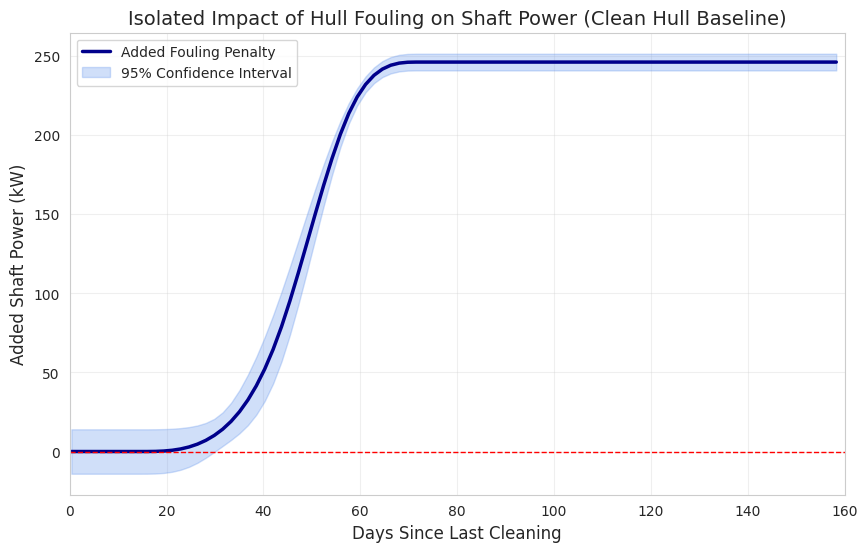

In [202]:
scaler = gam_pipeline.named_steps["preprocessor"].named_transformers_["numeric"].named_steps["scaler"]

# 2. Unscale the grid points so the X-axis is back in real "Days"
XX_unscaled = scaler.inverse_transform(XX)
real_days = XX_unscaled[:, fouling_idx]

# 3. Filter to only include days up to 160
mask = real_days <= 160
real_days_filtered = real_days[mask]
pdep_filtered = pdep[mask]
confi_filtered = confi[mask]


# Shift the curve to start at 0 for readability
# pyGAM's generate_X_grid creates a sorted array, so the 0th index is the minimum day
baseline_power = pdep_filtered[0]

# Subtract the baseline value from both the main prediction and the CI bounds
pdep_shifted = pdep_filtered - baseline_power
confi_shifted = confi_filtered - baseline_power

# 4. Plot the final, isolated Fouling Curve
plt.figure(figsize=(10, 6))

# Plot the main partial dependence line (using SHIFTED values)
plt.plot(real_days_filtered, pdep_shifted, color='darkblue', linewidth=2.5, label='Added Fouling Penalty')

# Plot the 95% Confidence Interval bounds (using SHIFTED values)
plt.fill_between(real_days_filtered, confi_shifted[:, 0], confi_shifted[:, 1], color='cornflowerblue', alpha=0.3, label='95% Confidence Interval')

# Formatting
plt.title("Isolated Impact of Hull Fouling on Shaft Power (Clean Hull Baseline)", fontsize=14)
plt.xlabel("Days Since Last Cleaning", fontsize=12)
plt.ylabel("Added Shaft Power (kW)", fontsize=12) # Updated label to be more intuitive
plt.axhline(y=0, color='red', linestyle='--', linewidth=1) # Baseline
plt.xlim(0, 160)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [203]:
# find average shaft power in the test set
average_test_power = y_test.mean()

# find the maximum value in the plot above
max_fouling_penalty = pdep_shifted.max()
max_fouling_penalty_percentage = (max_fouling_penalty / average_test_power) * 100

print(f'max fouling penalty (kW): {max_fouling_penalty:.2f} kW')
print(f'max fouling penalty percentage: {max_fouling_penalty_percentage:.2f} %')

max fouling penalty (kW): 246.33 kW
max fouling penalty percentage: 5.76 %


### 3.3.2.1 Fouling penalty by speed

In [204]:
simulation_df

,Avg Draft (Calculated),Draft Trim (Calculated),Days Since Last Cleaning,Vessel Hull Through Water Longitudinal Speed (knots),Vessel External Conditions Wind Relative Angle (degrees),Vessel External Conditions Wind Relative Speed (knots),Vessel External Conditions Sea Water Temperature (Provider S),Vessel External Conditions Wave Significant Height (Provider MB),Predicted Shaft Power
0,9.945,1.0,0,8,205.243173,21.467125,24.299006,2.012381,1269.569521
1,9.945,1.0,1,8,205.243173,21.467125,24.299006,2.012381,1269.569504
2,9.945,1.0,2,8,205.243173,21.467125,24.299006,2.012381,1269.569485
3,9.945,1.0,3,8,205.243173,21.467125,24.299006,2.012381,1269.569465
4,9.945,1.0,4,8,205.243173,21.467125,24.299006,2.012381,1269.569443
...,...,...,...,...,...,...,...,...,...
1958,9.945,1.0,146,14,205.243173,21.467125,24.299006,2.012381,6051.161957
1959,9.945,1.0,147,14,205.243173,21.467125,24.299006,2.012381,6051.161903
1960,9.945,1.0,148,14,205.243173,21.467125,24.299006,2.012381,6051.161851
1961,9.945,1.0,149,14,205.243173,21.467125,24.299006,2.012381,6051.161801


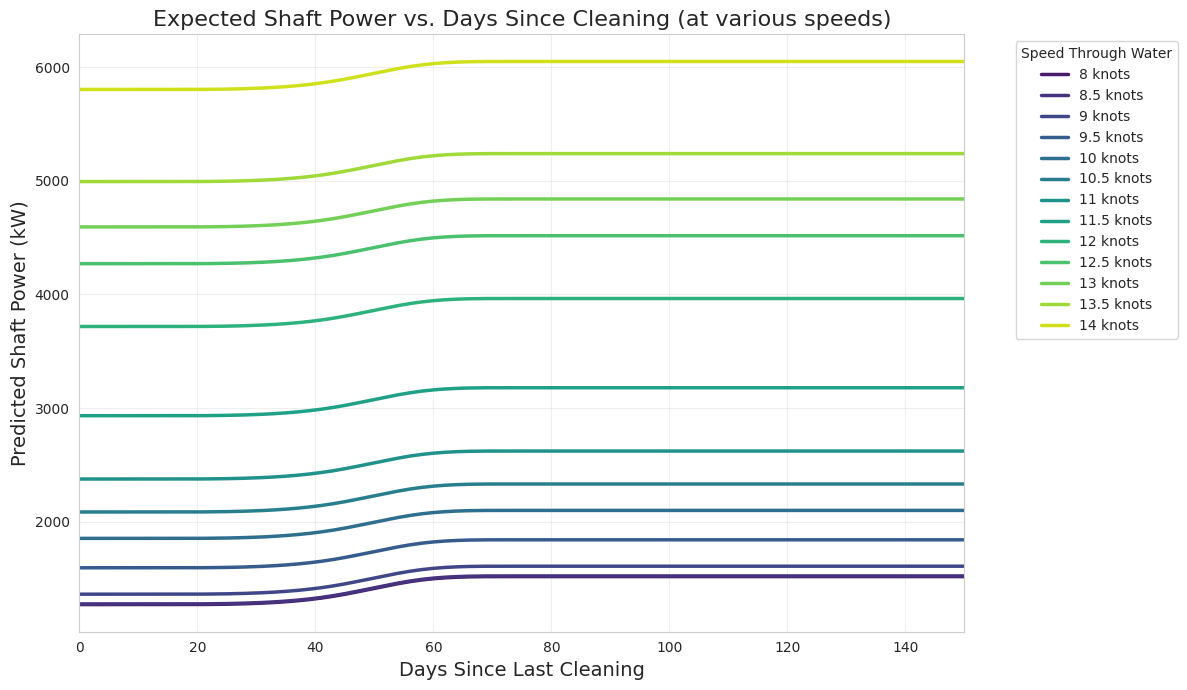

In [205]:

# overwrite the "Predicted Shaft Power" column in the simulation dataframe with the predicted values from the GAM model instead of the RF
simulation_df['Predicted Shaft Power'] = gam_pipeline.predict(simulation_df[all_predictive_variables])

# Set a nice color palette for the different speeds
unique_speeds = sorted(simulation_df['Vessel Hull Through Water Longitudinal Speed (knots)'].unique())
colors = sns.color_palette("viridis", len(unique_speeds))

plt.figure(figsize=(12, 7))

# Plot one line for each Speed
for i, speed in enumerate(unique_speeds):
    # Filter the dataframe for this specific speed
    subset = simulation_df[simulation_df['Vessel Hull Through Water Longitudinal Speed (knots)'] == speed]
    
    # Plot Days vs Predicted Power
    plt.plot(
        subset['Days Since Last Cleaning'], 
        subset['Predicted Shaft Power'], 
        linewidth=2.5, 
        color=colors[i],
        label=f"{speed} knots"
    )

# Formatting
plt.title("Expected Shaft Power vs. Days Since Cleaning (at various speeds)", fontsize=16)
plt.xlabel("Days Since Last Cleaning", fontsize=14)
plt.ylabel("Predicted Shaft Power (kW)", fontsize=14)
plt.xlim(0, 150)

# Add a legend to show which line is which speed
plt.legend(title="Speed Through Water", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout() # Ensures the legend isn't cut off
plt.show()


### 3.3.3. Speed through water

#### 3.3.3.1. Speed/power curve

Speed is at index: 3


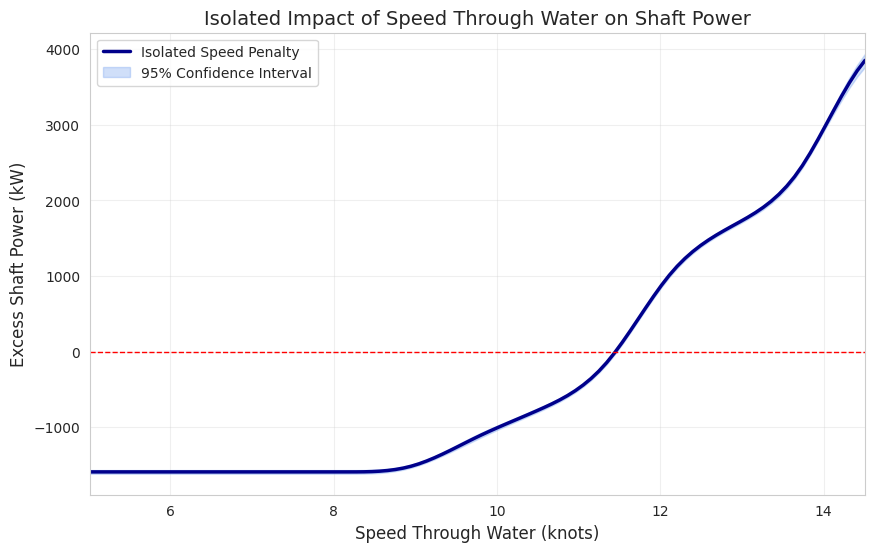

In [206]:
speed_idx = all_predictive_variables.index("Vessel Hull Through Water Longitudinal Speed (knots)")
print(f"Speed is at index: {speed_idx}")

# 2. Generate a perfectly spaced grid of 100 points for the speed feature
# This creates a synthetic array where ONLY the speed feature changes.
XX = actual_pygam_model.generate_X_grid(term=speed_idx)

# 3. Extract the partial dependence (the isolated kW penalty) and the 95% confidence intervals
pdep, confi = actual_pygam_model.partial_dependence(term=speed_idx, X=XX, width=0.95)

# 4. We only want to plot the X-axis for the speed variable itself
x_axis_values = XX[:, speed_idx]

# 2. Unscale the grid points so the X-axis is back in real "Days"
XX_unscaled = scaler.inverse_transform(XX)
real_speed = XX_unscaled[:, speed_idx]

# 3. Filter to only include days up to 160
mask = real_speed <= 160
real_speed_filtered = real_speed[mask]
pdep_filtered = pdep[mask]
confi_filtered = confi[mask]

# 4. Plot the final, isolated Speed Curve
plt.figure(figsize=(10, 6))

plt.plot(real_speed, pdep, color='darkblue', linewidth=2.5, label='Isolated Speed Penalty')
plt.fill_between(real_speed, confi[:, 0], confi[:, 1], color='cornflowerblue', alpha=0.3, label='95% Confidence Interval')

plt.title("Isolated Impact of Speed Through Water on Shaft Power", fontsize=14)
plt.xlabel("Speed Through Water (knots)", fontsize=12) 
plt.ylabel("Excess Shaft Power (kW)", fontsize=12)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.xlim(real_speed.min(), real_speed.max()) 

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()